# Exercises XP Gold - Machine Learning Evaluation Metrics
GenAI & Machine Learning Bootcamp 2025 - Part Time
Author: [Ton Nom]

## Exercise 1: Analyzing Confusion Matrix

- **True Positive (TP)**: Email is spam, model predicts spam.
- **True Negative (TN)**: Email is not spam, model predicts not spam.
- **False Positive (FP)**: Email is not spam, but model predicts spam.
- **False Negative (FN)**: Email is spam, but model predicts not spam.

Formulas:
- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1-Score = 2 * (Precision * Recall) / (Precision + Recall)

In [1]:
# Example confusion matrix values
TP, TN, FP, FN = 80, 900, 50, 20

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.93
Precision: 0.62
Recall: 0.80
F1-Score: 0.70


## Exercise 2: Evaluating Trade-offs in Metrics

- In medical diagnosis, **Recall > Precision** because missing a sick patient (FN) is worse than a false alarm (FP).
- Precision becomes more important in contexts like automatic treatment → better avoid harming healthy patients.
- Accuracy alone is misleading in imbalanced datasets (e.g., predicting all "not sick" still gives high accuracy).

## Exercise 3: Cross-Validation and Learning Curves

- **K-Fold CV**: split dataset into K equal parts, rotate train/test.
- **Stratified K-Fold**: preserves class proportions in each fold.
  - For regression (housing prices), K-Fold is enough.
  - For classification with imbalance, Stratified is better.

- **Learning Curves**: plot training vs validation performance.
  - Underfitting: both low.
  - Overfitting: training high, validation low.
  - Fixes: regularization, more data, simpler/more complex models as needed.

## Exercise 4: Impact of Class Imbalance

- Example: Rare disease dataset (2% positives).
- Accuracy is misleading: predicting all "healthy" = 98% accuracy.
- Better metrics: Precision, Recall, F1, ROC-AUC, PR-AUC.
- Strategies:
  - Use resampling (SMOTE, undersampling, oversampling).
  - Apply class weights.
  - Focus on recall and precision rather than accuracy.

## Exercise 5: Role of Threshold Tuning

- If threshold ↑ from 0.5 to 0.7:
  - Precision ↑ (fewer false positives).
  - Recall ↓ (more false negatives).

- Consequences:
  - Threshold too high → miss risky clients (bad for bank).
  - Threshold too low → reject too many good clients.

- ROC curve: plots TPR vs FPR.
- AUC: measures global performance.
- Helps choose optimal threshold balancing business needs.

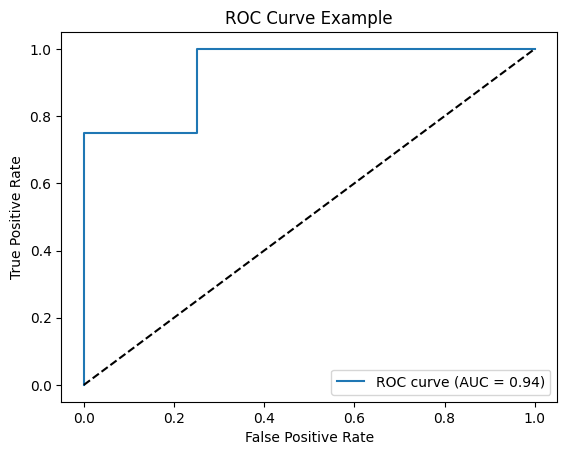

In [2]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Example probabilities and true labels
y_true = [0, 0, 1, 1, 0, 1, 0, 1]
y_scores = [0.1, 0.4, 0.35, 0.8, 0.2, 0.7, 0.3, 0.9]

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Example")
plt.legend()
plt.show()